# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [x] Inspect the shapes of the training and test sets to confirm their size and structure.
- [x] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [x] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
import numpy as np
import pandas as pd

from tensorflow.keras.datasets import fashion_mnist 
import random
import tensorflow as tf 

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout

2025-10-28 00:14:14.007314: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-28 00:14:14.059948: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-28 00:14:14.073293: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-28 00:14:14.181107: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-28 00:14:15.187296: W tensorflow/compiler/tf2

In [2]:
### data pre-process 

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
# x = input feature
# y = output label 

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]


In [3]:
### check tensorflow and keras version 

!pip list | grep -e tensorflow -e keras   ## Before !pip install tensorflow==2.17.0 keras==3.5.0

keras                              3.5.0
tensorflow                         2.17.0
tensorflow-estimator               2.6.0
tensorflow-io-gcs-filesystem       0.37.1


In [4]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [5]:
# Inspect the shapes of the datasets
print(f"Train Input X number: {X_train.shape[0]}, image size: {X_train.shape[1]} x {X_train.shape[2]}")
print(f"Train Label y number: {y_train.shape[0]}")
print(f"Test Input X number: {X_test.shape[0]}, image size: {X_test.shape[1]} x {X_test.shape[2]}")
print(f"Test Label y number: {y_test.shape[0]}")

Train Input X number: 60000, image size: 28 x 28
Train Label y number: 60000
Test Input X number: 10000, image size: 28 x 28
Test Label y number: 10000


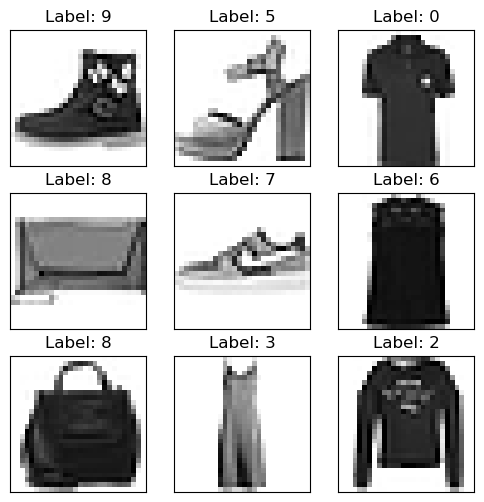

In [6]:
import matplotlib.pyplot as plt
# Verify the data looks as expected

# Selecting 9 random indices
random_indices = np.random.choice(len(X_test), 9, replace=False)

# Creating a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[random_indices[i]], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label: {y_test[random_indices[i]]}")

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

In [7]:
# Convert labels to one-hot encoding
# from tensorflow.keras.utils import to_categorical

print(f'Before one-hot encoding: {y_train[0]}')
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
print(f'After one-hot encoding: {y_train[0]}')


Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**: no issue here, data is expected as 28x28 image and the label y is for the classification

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [8]:
##### >>> 1. Build Model 
random.seed(111)
tf.random.set_seed(123)
model_base = Sequential()

# Input layer
model_base.add(Input(shape = (28,28))) # Input tensor specifying the shape
model_base.add(Flatten())  # Flattern to convert 2D to 1D
##Output layer
model_base.add(Dense(10))


model_base.summary()

##### >>> 2. Complie model 
from tensorflow.keras.optimizers import SGD

model_base.compile(
    loss='categorical_crossentropy', # Loss function
    # optimizer = 'Adam', 
    # Alternative: SGD
    optimizer=SGD(learning_rate = 0.00001, momentum = 0.9),
    metrics=['accuracy'] # Metrics to evaluate the model
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
%%time
##### >>> 3. Train model 

history = model_base.fit(X_train,   # Training data
                        y_train,    # Training label
                        epochs=5,   # Number of epochs
                        batch_size=32,  # Number of samples per batch
                        validation_split=0.2    # Use 20% of the data for validation
                        )


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1812 - loss: 3.2554 - val_accuracy: 0.1019 - val_loss: 3.6498
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 975us/step - accuracy: 0.1020 - loss: 3.5699 - val_accuracy: 0.0983 - val_loss: 3.2428
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 998us/step - accuracy: 0.1008 - loss: 4.1453 - val_accuracy: 0.0993 - val_loss: 7.6386
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 992us/step - accuracy: 0.1062 - loss: 7.6042 - val_accuracy: 0.1042 - val_loss: 7.6585
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1082 - loss: 8.2363 - val_accuracy: 0.1093 - val_loss: 8.6885
CPU times: user 10.9 s, sys: 1.36 s, total: 12.3 s
Wall time: 8.01 s


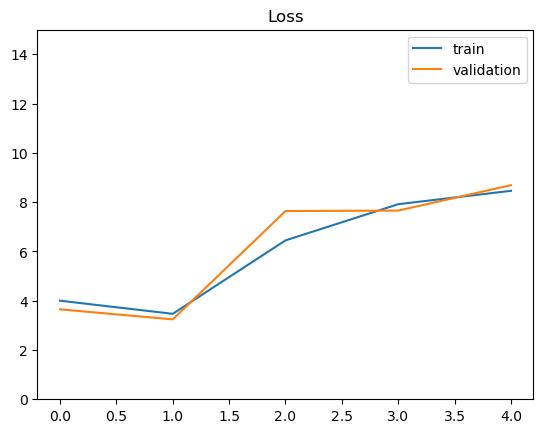

In [10]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.ylim(0, 15)
plt.legend(loc='best')
plt.title('Loss');

In [11]:
##### >>> 4. Evaluate the model with `model.evaluate()`

loss, accuracy = model_base.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - accuracy: 0.1104 - loss: 8.9299
Loss:     8.95
Accuracy: 11.05%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?


**>> Your answer here**:   


To properly assess the performance, the model is evaluated with three different random seed sets:

| Trial | random.seed | tf.random.set_seed | Loss | Accuracy |
| ----- | ----------- | ------------------ | ---- | -------- |
| 1*     | 111         | 123                | 8.95 | 11.05%   |*
| 2     | 575         | 457                | 8.73 | 14.65%   |
| 3     | 981         | 789                | 8.59 | 12.62%   |

The performance is not great as the accuracy is about 11% - 15%. This is because we used a linear regression model without any an actual neural network 

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [ ]:
help(Conv2D)

In [12]:
# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

random.seed(981)
tf.random.set_seed(789)


#### >>> 1. Create a simple CNN model
model_con2D = Sequential([
    
    # input layer
    Input(shape = (28,28,1)), # images are 28 x 28

    # hidden Conv2D layer
    Conv2D(32, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),                      # downsample by 2
    Conv2D(64, kernel_size=(3,3), activation='relu'),   # 64 filters
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),                                          # flatten to 1D vector
    Dense(128, activation='relu'),                      # fully connected hidden layer
    Dropout(0.5),                                       # optional regularization
    
    # output layer
    Dense(10, activation='softmax')                 
])

model_con2D.summary()

##### >>> 2. Complie model 
model_con2D.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='adam', 
    # Alternative Optimizer: 
    # SGD(learning_rate = 0.0001, momentum = 0.9),
    metrics=['accuracy'] # Metrics to evaluate the model
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
%%time
##### >>> 3. Train model 

history = model_con2D.fit(X_train,  # Training data
                        y_train,    # Training label
                        epochs=5,   # Number of epochs
                        batch_size=32,  # Number of samples per batch
                        validation_split=0.2    # Use 20% of the data for validation
)
                        


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7148 - loss: 0.7922 - val_accuracy: 0.8564 - val_loss: 0.3942
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8537 - loss: 0.4080 - val_accuracy: 0.8758 - val_loss: 0.3266
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8765 - loss: 0.3431 - val_accuracy: 0.8951 - val_loss: 0.2839
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8899 - loss: 0.3065 - val_accuracy: 0.9005 - val_loss: 0.2652
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8978 - loss: 0.2834 - val_accuracy: 0.9028 - val_loss: 0.2598
CPU times: user 6min 27s, sys: 15.8 s, total: 6min 43s
Wall time: 56.7 s


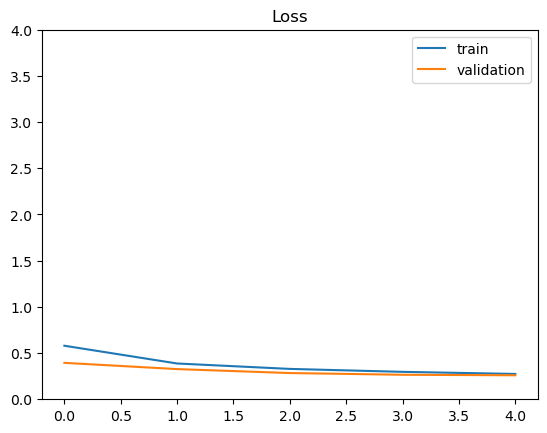

In [14]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.ylim(0, 4)
plt.legend(loc='best')
plt.title('Loss');

In [15]:
##### >>> 4. Evaluate the model

loss, accuracy = model_con2D.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9001 - loss: 0.2807
Loss:     0.28
Accuracy: 89.85%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**>> Your answer here**: 

Yes, we again tested the model with three different pairs of random.seed() and tf.random.set_seed(). It is very clear that the Lost is only 0.75 and the Accuracy increase to 72-74% with SGD optimizer. If using Adam optimizer, the accuracy can reach 89%.

| Trial | random.seed | tf.random.set_seed | Loss | Accuracy | Optimizer | 
| ----- | ----------- | ------------------ | ---- | -------- | ----------|
| 1     | 111         | 123                | 0.76 | 72.40%   | SGD(0.0001, 0.9) |
| 2     | 575         | 457                | 0.74 | 73.58%   | SGD(0.0001, 0.9) |
| 3     | 981         | 789                | 0.76 | 72.57%   | SGD(0.0001, 0.9) |
| 4*     | 981         | 789                | 0.28 | 89.85%   | Adam             |* shown here  


This is because CNN slides a 'filter' (kernels) across the image to detect local patters such as vertical edges, horizontal lines, and curves to detect the pattern. More interestingly, when switching optimizer from SGD to Adam, it improves the accuracy to almost 90% and the loss is reduced from 0.75 to 0.28.   

# 4. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

**>> Design of Experiment**:

To further understand the importance and the relationships among the hyperparameters, five different parameters were evaluated first using a traditional DOE approach. The factor showing the highest level of statistical significance will then be selected for further model evaluation.      


| Hyperparameter | Values Tested      |
|----------------|--------------------|
| filter 1 size  | [16, 32, 64]       |
| filter 2 size  | [32, 64, 128]      |
| Kernel Size    | [3, 5]             |
| Pool Size      | [2]                |
| Dropout Rate   | [0.2, 0.5]         |

In [16]:
# A-1: Using for a loop Test Hyperparameters
### >>> 1. define a function

def func_con2D(Shape, f1, f2, Kernel, Pool, Drop_r,lr=0.001):
    """
    A custumozed build CNN with two layers of Conv2D using `relu` for hiddlen network and `softmax` for the output layer

    Shape = (x,y,channel) | default shape=(28,28,1): 
        28: the height of the image in pixels
        28: the width of the image in pixels
        1: the number of color channels
    f1: filter number for the 1st cconvolution layer
    f2: filter number for the 2nd convoluktion layer
    Kernel = int, ex: (3,3), (5,5), etc
    Pool = int, ex: (3,3), (5,5), etc
    Drop_r = 0..1
    lr (learning rate), default 0.001 for adam
    """

    build_con2D = Sequential([
        # input layer
        Input(shape=Shape),

        # hidden Conv2D layer
        Conv2D(f1, kernel_size= (Kernel, Kernel), activation='relu'),
        MaxPooling2D(pool_size= (Pool, Pool)),                      # downsample by 2
        Conv2D(f2, kernel_size= (Kernel, Kernel), activation='relu'),   # 64 filters
        MaxPooling2D(pool_size= (Pool, Pool)),
        Flatten(),                                          # flatten to 1D vector
        Dense(128, activation='relu'),                      # fully connected hidden layer
        Dropout(Drop_r),                                       # optional regularization
    
        # output layer
        Dense(10, activation='softmax')
        ])    

    # print(build_con2D.summary())  # to pring summmary 
    # model compile
    build_con2D.compile(
        loss='categorical_crossentropy', # Loss function
        optimizer=Adam(learning_rate=lr), # Optimizer
        metrics=['accuracy'] # Metrics to evaluate the model
    )
    return build_con2D


In [17]:
# A-1: Using for a loop Test Hyperparameters
### >>> 2. for loop for model 

random.seed(981)
tf.random.set_seed(789)

# utilities 
import time
start_time = time.time() # start timer 

# conditions 
Shape =(28,28,1)
f1 = [16,32,64]
f2 = [32,64,128]
Kernel=[3,5]
Pool = [2]
drop_r =[0.2, 0.5]
results=[]
models=[]

for f_1 in f1:
    for f_2 in f2:
        for k in Kernel:
            for p in Pool:
                for r in drop_r:
                    print(f"filter_1_size: {f_1}, filter_2_size: {f_2}, kernel_size: {k}, pool_size: {p}, dropout_rate: {r}")

                    model_con2D_exp = func_con2D(Shape = Shape, 
                                            f1 = f_1, 
                                            f2 = f_2, 
                                            Kernel = k, 
                                            Pool= p, 
                                            Drop_r = r)
                    
                    history = model_con2D_exp.fit(
                        X_train,  # Training data
                        y_train,    # Training label
                        epochs=5,   # Number of epochs
                        batch_size=32,  # Number of samples per batch
                        validation_split=0.2,    # Use 20% of the data for validation
                    )
                    
                    # extract the best validation accuracy for this run
                    val_acc = max(history.history['val_accuracy'])
                    
                    results.append({
                        'f1': f_1,
                        'f2': f_2,
                        'kernel': k,
                        'pool': p,
                        'dropout': r,
                        'val_acc': val_acc
                    })

                    # Save model for later evaluation
                    models.append(model_con2D_exp)


end_time = time.time()  # stop timer
run_time = end_time - start_time
print(f"Total trainng time: {run_time/60:.4f} minutes") 



filter_1_size: 16,filter_2_size: 32,kernel_size: 3,pool_size: 2,dropout_rate: 0.2
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7322 - loss: 0.7387 - val_accuracy: 0.8596 - val_loss: 0.3839
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8633 - loss: 0.3741 - val_accuracy: 0.8772 - val_loss: 0.3277
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8827 - loss: 0.3201 - val_accuracy: 0.8886 - val_loss: 0.2970
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8955 - loss: 0.2863 - val_accuracy: 0.8951 - val_loss: 0.2821
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9038 - loss: 0.2608 - val_accuracy: 0.8971 - val_loss: 0.2830
filter_1_size: 16,filter_2_size: 32,kernel_size: 3,pool_size: 2,dropout_rate: 0.5
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6943 - loss: 0.8556 - val_accuracy: 0.8467 - val_loss: 0.4100
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accurac

In [18]:
print(f"Total trainng time: {run_time/60:.4f} minutes") 

Total trainng time: 52.4963 minutes


In [20]:
df_result=pd.DataFrame(results)
df_result

,f1,f2,kernel,pool,dropout,val_acc
0,16,32,3,2,0.2,0.897083
1,16,32,3,2,0.5,0.893000
2,16,32,5,2,0.2,0.896667
3,16,32,5,2,0.5,0.898250
4,16,64,3,2,0.2,0.899750
5,16,64,3,2,0.5,0.899750
6,16,64,5,2,0.2,0.900583
7,16,64,5,2,0.5,0.898917
8,16,128,3,2,0.2,0.905583
9,16,128,3,2,0.5,0.901417


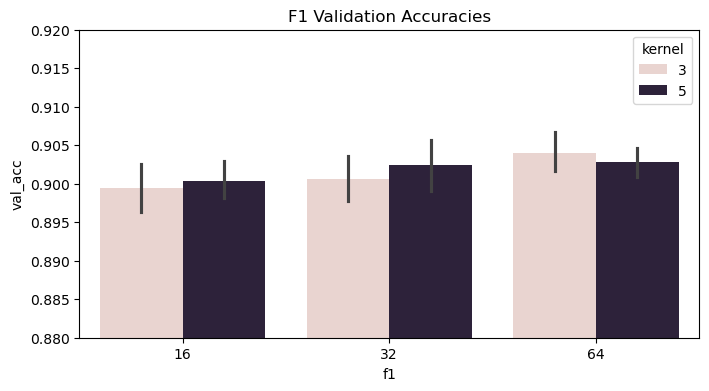

In [29]:
###  Visualize: f1

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.barplot(data=df_result, x='f1', y='val_acc', hue='kernel')
plt.ylim(0.88, 0.92)  # zoom into this range
plt.title('F1 Validation Accuracies')
plt.show()

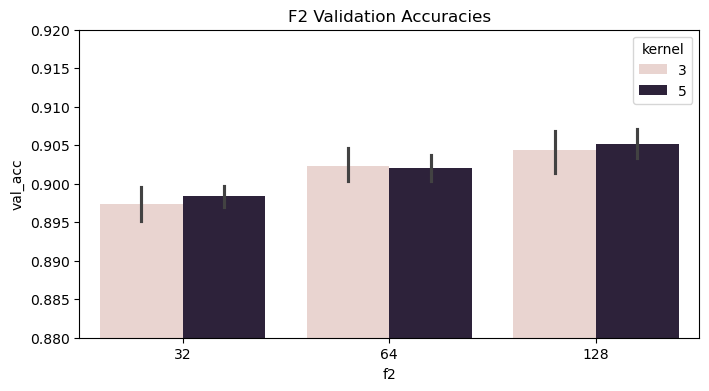

In [30]:
###  Visualize: f2

plt.figure(figsize=(8,4))
sns.barplot(data=df_result, x='f2', y='val_acc', hue='kernel')
plt.ylim(0.88, 0.92)  # zoom into this range
plt.title('F2 Validation Accuracies')
plt.show()

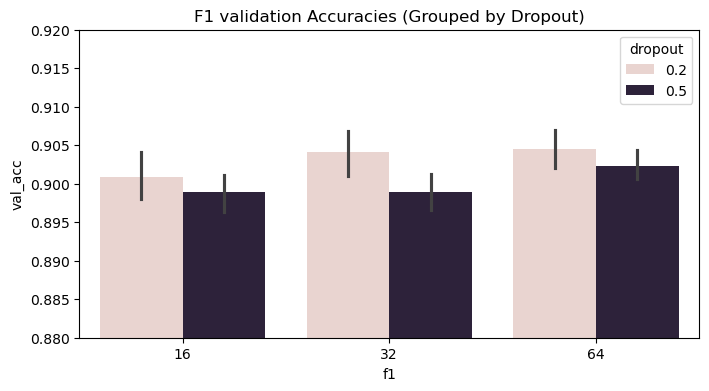

In [31]:
plt.figure(figsize=(8,4))
sns.barplot(df_result, x='f1', y='val_acc', hue='dropout')
plt.ylim(0.88, 0.92)  # zoom into this range
plt.title('F1 validation Accuracies (Grouped by Dropout)')
plt.show()

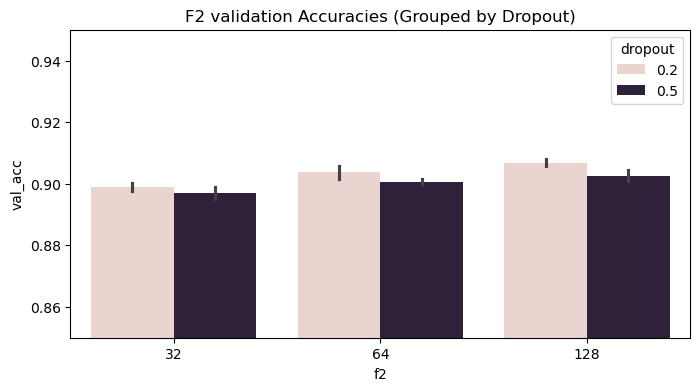

In [32]:
plt.figure(figsize=(8,4))
sns.barplot(df_result, x='f2', y='val_acc', hue='dropout')
plt.ylim(0.85, 0.95)
plt.title('F2 validation Accuracies (Grouped by Dropout)')
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Assume interaction: f1 x f2, f1 x kernal, f2 x kernel

doe_model = ols('val_acc ~ C(f1)*C(f2) + C(f1)*C(kernel) + C(f2)*C(kernel) + C(dropout)', data=df_result).fit()

anova_table = sm.stats.anova_lm(doe_model, typ=2)  # Type II ANOVA (balanced design)
print(anova_table)



                   sum_sq    df          F        PR(>F)
C(f1)            0.000073   2.0  13.257865  1.890209e-04
C(f2)            0.000287   2.0  52.040614  7.290967e-09
C(kernel)        0.000002   1.0   0.831814  3.721002e-01
C(dropout)       0.000085   1.0  30.960975  1.602290e-05
C(f1):C(f2)      0.000016   4.0   1.460665  2.495923e-01
C(f1):C(kernel)  0.000015   2.0   2.730782  8.827544e-02
C(f2):C(kernel)  0.000003   2.0   0.595949  5.600938e-01
Residual         0.000058  21.0        NaN           NaN


In [ ]:
### From the ANOVA table above:tThe significance level f2 > dropout > f1 


# A-2: Select the condition to be evaluated 
# Evauate the model with f2 = 32, 64, 128 

df_result[(df_result['kernel']==5) & (df_result['dropout']== 0.2) & (df_result['f1'].isin([16,32]))]


,f1,f2,kernel,pool,dropout,val_acc
2,16,32,5,2,0.2,0.896667
6,16,64,5,2,0.2,0.900583
10,16,128,5,2,0.2,0.905917
14,32,32,5,2,0.2,0.900417
18,32,64,5,2,0.2,0.905333
22,32,128,5,2,0.2,0.909417


In [59]:
# set 1: f1 = 16, kernel = 5, dropout = 0.2, f2 = [32, 64, 128] 

set1 = [2,6,10]
for i in set1:

    loss, accuracy = models[i].evaluate(X_test, y_test)

    print(f'run index:{i}, Loss:     {loss:.2f}')
    print(f'run index:{i}, Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8935 - loss: 0.2960
run index:2, Loss:     0.30
run index:2, Accuracy: 89.22%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8975 - loss: 0.2982
run index:6, Loss:     0.29
run index:6, Accuracy: 89.55%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9013 - loss: 0.2861
run index:10, Loss:     0.28
run index:10, Accuracy: 89.96%


In [61]:
# set2: f1 = 32, kernel = 5, dropout = 0.2, f2 = [32, 64, 128] 

set2 = [14,18,22]
for i in set2:

    loss, accuracy = models[i].evaluate(X_test, y_test)

    print(f'run index:{i}, Loss:     {loss:.2f}')
    print(f'run index:{i}, Accuracy: {accuracy*100:.2f}%')


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8905 - loss: 0.3171
run index:14, Loss:     0.32
run index:14, Accuracy: 88.78%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9018 - loss: 0.2957
run index:18, Loss:     0.29
run index:18, Accuracy: 90.00%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9053 - loss: 0.2845
run index:22, Loss:     0.28
run index:22, Accuracy: 90.30%


In [62]:
## B. Test presence or absence of regularization
#  will set the dropout = 0 with the oringal setting filter_size 1 = 32, filter_size2 = 64

model_con2D_no_drop = func_con2D(Shape=(28,28,1), 
                             f1 = 32, 
                             f2 = 64, 
                             Kernel = 3, 
                             Pool= 2, 
                             Drop_r = 0)

history = model_con2D_no_drop.fit(
    X_train,  # Training data
    y_train,    # Training label
    epochs=5,   # Number of epochs
    batch_size=32,  # Number of samples per batch
    validation_split=0.2    # Use 20% of the data for validation
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7694 - loss: 0.6421 - val_accuracy: 0.8663 - val_loss: 0.3665
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8777 - loss: 0.3334 - val_accuracy: 0.8877 - val_loss: 0.3040
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8968 - loss: 0.2802 - val_accuracy: 0.8948 - val_loss: 0.2862
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9099 - loss: 0.2443 - val_accuracy: 0.8989 - val_loss: 0.2711
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9207 - loss: 0.2135 - val_accuracy: 0.9026 - val_loss: 0.2688


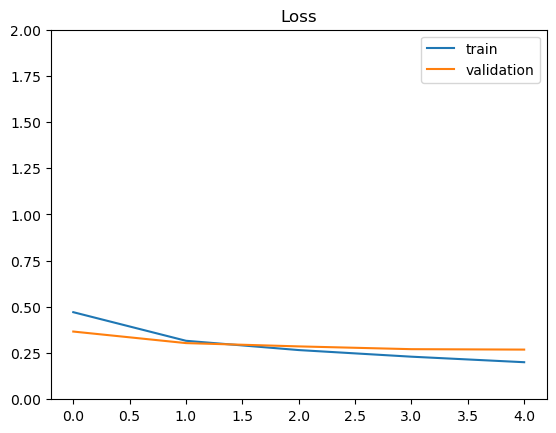

In [63]:
# plot 

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Loss');

In [64]:
loss, accuracy = model_con2D_no_drop.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9026 - loss: 0.2810
Loss:     0.28
Accuracy: 90.01%


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**>> Your answer here**:   
1. There is a very tiny increase of around 1% for the CNN, Most of CNN show validation accuracy around 89-90%, which makes it very challenges to understand if 1% difference is significant in real-world application.   

2. From DOE, we learned that the top 3 hyperparameters show the most significant levels are: `f2` > `dropout` > `f1` 

3. No dropout still shows an accuracy of 90% when evaluating using test data.

4. The best performance is likely when combining the following hyperparameters:

    - most frequent f1: `32`
    - most frequent f2: `128`
    - most frequent kernel: `3`
    - most frequent pool: `2`
    - most frequent dropout: `0.2`


# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [76]:
top10 = df_result.sort_values('val_acc',ascending=False).head(10) # the top 10
top10
# the one show the best result has run index = 22

,f1,f2,kernel,pool,dropout,val_acc
22,32,128,5,2,0.2,0.909417
32,64,128,3,2,0.2,0.909083
28,64,64,3,2,0.2,0.906667
33,64,128,3,2,0.5,0.906000
10,16,128,5,2,0.2,0.905917
34,64,128,5,2,0.2,0.905833
16,32,64,3,2,0.2,0.905667
8,16,128,3,2,0.2,0.905583
20,32,128,3,2,0.2,0.905417
18,32,64,5,2,0.2,0.905333


In [77]:
# print ou the best model 
print(f"most frequent f1: {df_result.sort_values('val_acc',ascending=False).head(10).value_counts('f1').idxmax()}")
print(f"most frequent f2: {df_result.sort_values('val_acc',ascending=False).head(10).value_counts('f2').idxmax()}")
print(f"most frequent kernel: {df_result.sort_values('val_acc',ascending=False).head(10).value_counts('kernel').idxmax()}")
print(f"most frequent pool: {df_result.sort_values('val_acc',ascending=False).head(10).value_counts('pool').idxmax()}")
print(f"most frequent dropout: {df_result.sort_values('val_acc',ascending=False).head(10).value_counts('dropout').idxmax()}")

most frequent f1: 32
most frequent f2: 128
most frequent kernel: 3
most frequent pool: 2
most frequent dropout: 0.2


In [78]:
### Evaluate model 22 
loss, accuracy = models[22].evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9053 - loss: 0.2845
Loss:     0.28
Accuracy: 90.30%


In [ ]:
### >>> 2. Re-run the best model, just to check 

model_con2D_opt = func_con2D(Shape=(28,28,1), 
                             f1 = 32, 
                             f2 = 128, 
                             Kernel = 3, 
                             Pool= 2, 
                             Drop_r = 0.2)

history = model_con2D_opt.fit(
    X_train,  # Training data
    y_train,    # Training label
    epochs=5,   # Number of epochs
    batch_size=32,  # Number of samples per batch
    validation_split=0.2    # Use 20% of the data for validation
    )


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7608 - loss: 0.6628 - val_accuracy: 0.8763 - val_loss: 0.3401
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8775 - loss: 0.3380 - val_accuracy: 0.8919 - val_loss: 0.2903
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8950 - loss: 0.2856 - val_accuracy: 0.9012 - val_loss: 0.2753
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9062 - loss: 0.2504 - val_accuracy: 0.9104 - val_loss: 0.2512
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9165 - loss: 0.2212 - val_accuracy: 0.9123 - val_loss: 0.2478


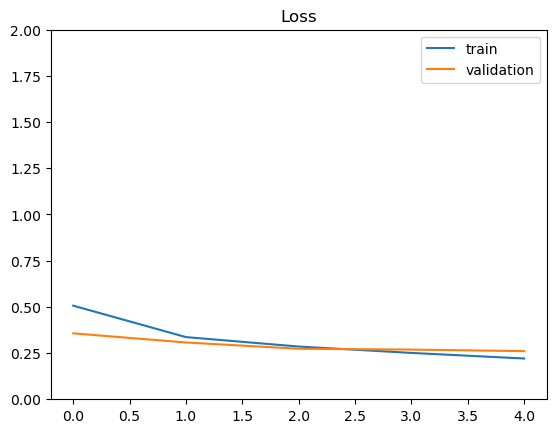

In [80]:
# plot 

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Loss');

In [83]:
##### >>> 3. Evaluate the model

loss, accuracy = model_con2D_opt.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9013 - loss: 0.2762
Loss:     0.28
Accuracy: 90.08%


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**>> Your answer here**

The final model performs substantially better, achieving an accuracy of approximately 90.26%, which represents an 8-fold improvement over the linear model (11%). However, adding two convolutional layers resulted in only a 1% improvement compared to the original setup (f1 = 32, f2 = 64, kernel_size = (3,3), pool_size = (2,2), dropout_rate = 0.5).

As mentioned previously, it remains unclear whether this 1% gain in a bench setting would translate meaningfully to real-world scenarios.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.